In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df = pd.read_csv(r"D:\DATASETS\Regression Data sets\weight-height.csv")

In [6]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [7]:
df.shape

(10000, 3)

### Feature Selection

In [8]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [9]:
df.columns

Index(['Gender', 'Height', 'Weight'], dtype='object')

In [10]:
df.drop("Gender", axis = 1)

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [11]:
df.drop("Gender", axis = 1, inplace = True)

In [12]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


### NaNs

In [13]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [14]:
df.isna()

,Height,Weight
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,False,False


In [15]:
df.isna().sum()

Height    0
Weight    0
dtype: int64

### Error Detection

In [16]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


<Axes: >

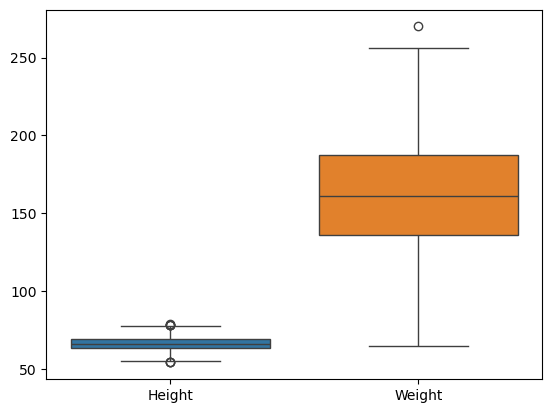

In [17]:
sns.boxplot(df)

<Axes: ylabel='Height'>

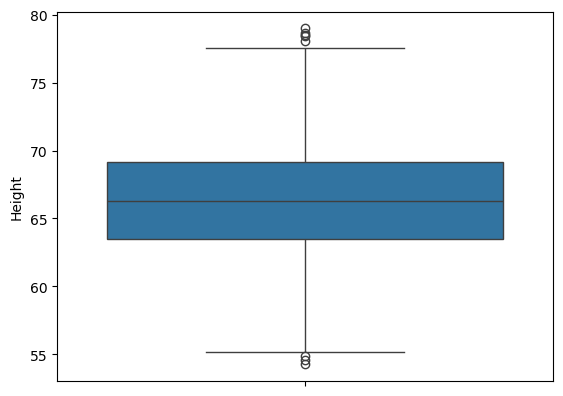

In [18]:
sns.boxplot( df["Height"])

<Axes: ylabel='Weight'>

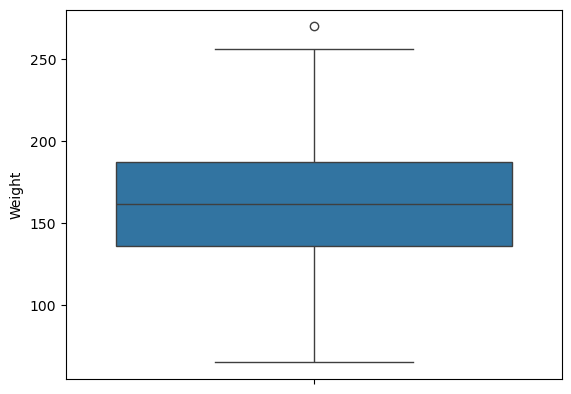

In [19]:
sns.boxplot( df["Weight"] )

In [20]:
df["Height"]

0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64

In [21]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [22]:
q1 = df["Height"].quantile(0.25)

In [23]:
q1

np.float64(63.505620480000005)

In [24]:
q3 = df["Height"].quantile(0.75)

In [25]:
q3

np.float64(69.17426172750001)

In [26]:
iqr = q3 - q1

In [27]:
iqr

np.float64(5.668641247500005)

In [28]:
lower = q1 - (1.5 * iqr)

In [29]:
upper = q3 + (1.5 * iqr)

In [30]:
lower

np.float64(55.00265860875)

In [31]:
upper

np.float64(77.67722359875002)

In [32]:
df["Height"] < lower

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: Height, Length: 10000, dtype: bool

In [33]:
df[ df["Height"] < lower ]

,Height,Weight
6624,54.616858,71.393749
7294,54.873728,78.606670
9285,54.263133,64.700127


In [34]:
df["Height"] > upper

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: Height, Length: 10000, dtype: bool

In [35]:
df[ df["Height"] > upper ]

,Height,Weight
994,78.095867,255.690835
1317,78.462053,227.342565
2014,78.998742,269.989698
3285,78.528210,253.889004
3757,78.621374,245.733783


In [36]:
(df["Height"] < lower) | (df["Height"] > upper)

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: Height, Length: 10000, dtype: bool

In [37]:
df[ (df["Height"] < lower) | (df["Height"] > upper) ]

,Height,Weight
994,78.095867,255.690835
1317,78.462053,227.342565
2014,78.998742,269.989698
3285,78.528210,253.889004
3757,78.621374,245.733783
6624,54.616858,71.393749
7294,54.873728,78.606670
9285,54.263133,64.700127


In [38]:
df[ (df["Height"] < lower) | (df["Height"] > upper) ]

,Height,Weight
994,78.095867,255.690835
1317,78.462053,227.342565
2014,78.998742,269.989698
3285,78.528210,253.889004
3757,78.621374,245.733783
6624,54.616858,71.393749
7294,54.873728,78.606670
9285,54.263133,64.700127


### Capping

In [39]:
df.shape

(10000, 2)

In [40]:
df["Height"]

0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64

In [41]:
df["Height"].map(lambda x :  lower if x < lower else   upper if x > upper  else x)

0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64

In [42]:
df["Height"] = df["Height"].map(lambda x :  lower if x < lower else   upper if x > upper  else x)

In [43]:
df[ (df["Height"] < lower) | (df["Height"] > upper) ]

,Height,Weight


<Axes: ylabel='Height'>

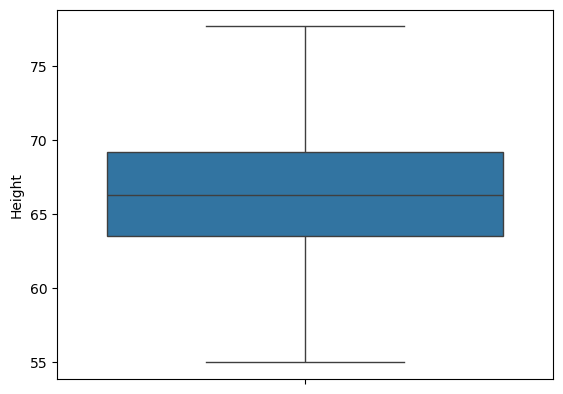

In [44]:
sns.boxplot(df["Height"])

## Weight Column

In [45]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [46]:
df["Weight"]

0       241.893563
1       162.310473
2       212.740856
3       220.042470
4       206.349801
           ...    
9995    136.777454
9996    170.867906
9997    128.475319
9998    163.852461
9999    113.649103
Name: Weight, Length: 10000, dtype: float64

<Axes: ylabel='Weight'>

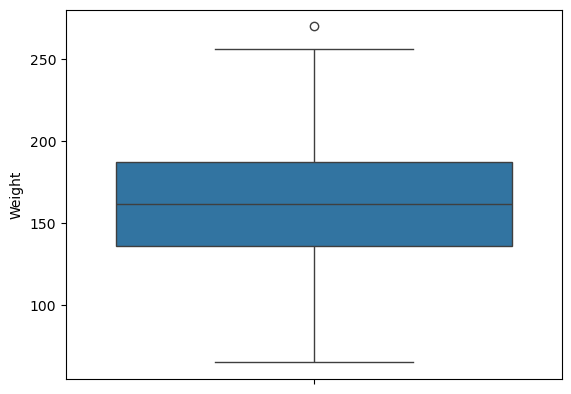

In [47]:
sns.boxplot(df["Weight"])

In [48]:
qw1 = df["Weight"].quantile(0.25)

In [49]:
qw1

np.float64(135.818051325)

In [50]:
qw3 = df["Weight"].quantile(0.75)

In [51]:
qw3

np.float64(187.16952485)

In [52]:
df["Weight"].describe()

count    10000.000000
mean       161.440357
std         32.108439
min         64.700127
25%        135.818051
50%        161.212928
75%        187.169525
max        269.989698
Name: Weight, dtype: float64

In [53]:
iqrw = qw3 - qw1

In [54]:
iqrw

np.float64(51.35147352499999)

In [55]:
lowerlimit = qw1 - (1.5 * iqrw)

In [56]:
lowerlimit

np.float64(58.790841037500016)

In [57]:
upperlimit = qw3 + (1.5 * iqrw)

In [58]:
upperlimit

np.float64(264.19673513749996)

### Errors Less than Lower Limit

In [59]:
df["Weight"] < lowerlimit

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: Weight, Length: 10000, dtype: bool

In [60]:
df[ df["Weight"] < lowerlimit ]

,Height,Weight


In [61]:
df["Weight"] > upperlimit

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: Weight, Length: 10000, dtype: bool

In [62]:
df[df["Weight"] > upperlimit]

,Height,Weight
2014,77.677224,269.989698


In [63]:
df.drop(2014)

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [64]:
df.drop(2014, inplace = True)

In [65]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


<Axes: ylabel='Height'>

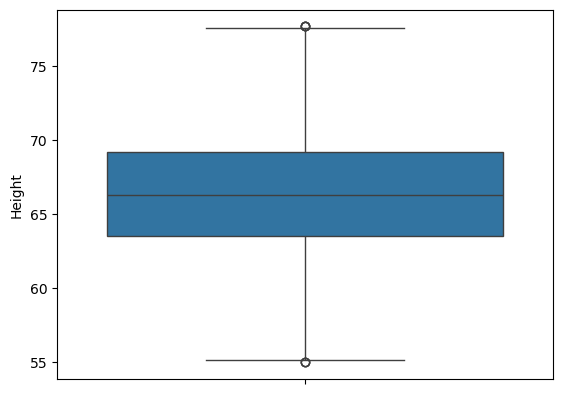

In [66]:
sns.boxplot(df["Height"])

<Axes: ylabel='Weight'>

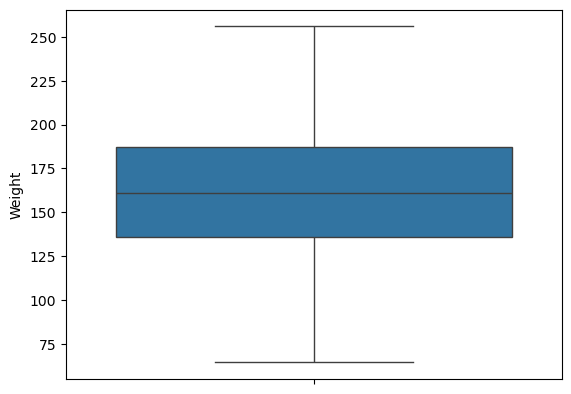

In [67]:
sns.boxplot(df["Weight"])

### Encoding

In [68]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [69]:
df.dtypes

Height    float64
Weight    float64
dtype: object

### Data Separation

In [70]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [71]:
df["Height"]

0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 9999, dtype: float64

In [72]:
type(df["Height"])

pandas.core.series.Series

In [73]:
pd.DataFrame(df["Height"])

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


In [74]:
X = df[["Height"]]

In [75]:
X

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
...,...
9995,66.172652
9996,67.067155
9997,63.867992
9998,69.034243


In [76]:
y = df["Weight"]

In [77]:
y

0       241.893563
1       162.310473
2       212.740856
3       220.042470
4       206.349801
           ...    
9995    136.777454
9996    170.867906
9997    128.475319
9998    163.852461
9999    113.649103
Name: Weight, Length: 9999, dtype: float64

In [78]:
type(X)

pandas.core.frame.DataFrame

In [79]:
type(y)

pandas.core.series.Series

### Data Splitting

In [80]:
from sklearn.model_selection import train_test_split

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [120]:
X.head(10)

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796
5,67.253016
6,68.785081
7,68.348516
8,67.018950
9,63.456494


In [121]:
X_train.head()

,Height
9254,61.391644
1561,74.697637
1670,68.507815
6087,65.797516
7333,67.151338


In [122]:
X_test.head()

,Height
5345,55.336492
7445,65.145381
1731,66.398128
8720,66.207354
4522,70.770357


In [123]:
from sklearn.linear_model import LinearRegression

In [124]:
lr_model = LinearRegression()

In [125]:
lr_model

LinearRegression()

In [126]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [127]:
lr_model.intercept_

np.float64(-349.3847046503304)

In [128]:
lr_model.coef_

array([7.69799186])

In [129]:
lr_model.score(X_test, y_test)

0.8644431269717455

In [130]:
lr_model.score(X_test, y_test)* 100

86.44431269717455

### Auto Random State

In [135]:
scorelist = []
for i in range(1000):
    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.20, random_state= i)
    linreg_model = LinearRegression()
    linreg_model.fit(Xtrain, ytrain)
    sc = linreg_model.score(Xtest, ytest)
    scorelist.append(sc)
# print(scorelist)
m = max(scorelist)
print("Max Score :", m)
rs = scorelist.index(m)
print("Random State :",rs)

Max Score : 0.870529204706708
Random State : 187
